In [ ]:
import os
os.listdir("/content")

['.config', 'sample_data']

In [ ]:
!apt-get install -y ffmpeg
!pip install pydub


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.


In [ ]:
from pydub import AudioSegment

ogg_file = "/content/WhatsApp Ptt 2026-02-13 at 09.51.53.ogg"
wav_file = "/content/patient_voice.wav"

audio = AudioSegment.from_file(ogg_file, format="ogg")
audio.export(wav_file, format="wav")

print("Conversion successful: patient_voice.wav")


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


FileNotFoundError: [Errno 2] No such file or directory: '/content/WhatsApp Ptt 2026-02-13 at 09.51.53.ogg'

In [ ]:
os.listdir("/content")


['.config', 'sample_data']

In [ ]:
from IPython.display import Audio
Audio("/content/patient_voice.wav")


In [ ]:
!pip install -U openai-whisper


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 19.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803980 sha256=e882238c2ef11314e099f7f78d86e20d5101fc89cb171a2441e176e9967a3c35
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper


In [ ]:
import whisper

model = whisper.load_model("base")
result = model.transcribe("/content/patient_voice.wav")

print(result["text"])


In [ ]:
import os
os.listdir("/content")


['.config',
 'WhatsApp Ptt 2026-02-13 at 09.51.53.ogg',
 'patient_voice.wav',
 'sample_data']

In [ ]:
!apt-get install -y ffmpeg
!pip install pydub



Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.


In [ ]:
from pydub import AudioSegment

ogg_file = "/content/voice.ogg"
wav_file = "/content/voice_telugu.wav"

audio = AudioSegment.from_file(ogg_file, format="ogg")
audio.export(wav_file, format="wav")

print("Telugu audio converted to WAV")


Telugu audio converted to WAV


In [ ]:
from IPython.display import Audio
Audio("/content/voice_telugu.wav")


In [ ]:
!pip install -U openai-whisper


In [ ]:
import whisper
model = whisper.load_model("base")


In [ ]:
result = model.transcribe(
    "/content/voice_telugu.wav",
    task="translate"   # Telugu → English
)

print("Translated English Text:")
print(result["text"])


Translated English Text:
 Later I is still older. Many of these to whom clear, but may be I do the wrong thing. And aside from that one by one. Coming to take a bite.


In [ ]:
!pip install -U datasets soundfile librosa


In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "ekacare/eka-medical-asr-evaluation-dataset",
    "en"
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some datasets params were ignored: ['default_preview_rows']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.
Some datasets params were ignored: ['default_preview_rows']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


In [ ]:
dataset


DatasetDict({
    test: Dataset({
        features: ['md5_text', 'file_name', 'audio', 'md5_audio', 'duration', 'text', 'audio_language', 'text_language', 'session_id', 'speaker', 'type_concept', 'recording_context', 'medical_entities'],
        num_rows: 3619
    })
})

In [ ]:
sample = dataset["test"][0]
sample


{'md5_text': '05e1834395bd772db887a07769e53c3d',
 'file_name': '/250427/ce-73d4588f-143b-4ffb-8944-a8df7f811c16/7.m4a',
 'audio': <datasets.features._torchcodec.AudioDecoder at 0x7a468e463530>,
 'md5_audio': 'df654cc44ffd1fd350e960c4b3555573',
 'duration': 10.496000289916992,
 'text': 'not having adequate rest. Okay okay. So that continues for better part of the day. Hmm, hmm, hmm. Then',
 'audio_language': 'en',
 'text_language': 'en',
 'session_id': 'ce-73d4588f-143b-4ffb-8944-a8df7f811c16',
 'speaker': None,
 'type_concept': 'misc_medical',
 'recording_context': 'conversation',
 'medical_entities': '[["adequate rest", "advices", [[11, 24]]]]'}

In [ ]:
from IPython.display import Audio

Audio(
    sample["audio"]["array"],
    rate=sample["audio"]["sampling_rate"]
)


In [ ]:
import soundfile as sf
import os

os.makedirs("/content/eka_audio", exist_ok=True)

for i in range(10):  # save first 10 samples
    audio = dataset["test"][i]["audio"]
    sf.write(
        f"/content/eka_audio/sample_{i}.wav",
        audio["array"],
        audio["sampling_rate"]
    )

print("WAV files saved")


WAV files saved


In [ ]:
!pip install -U openai-whisper


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 18.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803980 sha256=bf34285c1d46f4ca63d43bfa69896dcf48e9cc80c770b25c2225824c04814256
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper


In [ ]:

 import whisper

model = whisper.load_model("base")

result = model.transcribe("/content/eka_audio/sample_0.wav")

print("Whisper Output:", result["text"])
print("Ground Truth:", dataset["test"][0]["text"])


ModuleNotFoundError: No module named 'whisper'

In [ ]:
!pip install datasets transformers torchaudio accelerate


In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "ekacare/eka-medical-asr-evaluation-dataset",
    split="test"
)

print(dataset)


Some datasets params were ignored: ['default_preview_rows']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.
Some datasets params were ignored: ['default_preview_rows']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


Dataset({
    features: ['md5_text', 'file_name', 'audio', 'md5_audio', 'duration', 'text', 'audio_language', 'text_language', 'session_id', 'speaker', 'type_concept', 'recording_context', 'medical_entities'],
    num_rows: 3619
})


In [ ]:
sample = dataset[9]

print(sample["text"])      # Ground truth
print(sample["audio"])     # Audio object


plus,there was this issue of,stomach ache, and,yeah, so we want to give him digene because I don't think it's a problem, it's a big problem.


In [ ]:
sample = dataset[9]

patient_text = sample["text"]

print("Patient Text:")
print(patient_text)


Patient Text:
plus,there was this issue of,stomach ache, and,yeah, so we want to give him digene because I don't think it's a problem, it's a big problem.


In [ ]:
medical_prompt = f"""
You are a clinical decision support assistant.

Analyze the patient statement carefully and do the following:
1. Extract symptoms mentioned
2. Identify likely minor or major condition
3. Assess severity (Low / Medium / High)
4. Suggest general advice (not diagnosis)
5. Explain reasoning only from the text

Patient statement:
\"\"\"{patient_text}\"\"\"
"""


In [ ]:
from huggingface_hub import login

login()


In [ ]:
from transformers import pipeline

llm = pipeline(
    "text-generation",
    model="meta-llama/Meta-Llama-3-8B-Instruct",
    device_map="auto",
    max_new_tokens=300
)


OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/meta-llama/Meta-Llama-3-8B-Instruct.
403 Client Error. (Request ID: Root=1-698ffaed-6d1ef7a16f21d8862018b6d2;67d0842f-b334-4d92-90be-a5c21b90c9ce)

Cannot access gated repo for url https://huggingface.co/meta-llama/Meta-Llama-3-8B-Instruct/resolve/main/config.json.
Your request to access model meta-llama/Meta-Llama-3-8B-Instruct is awaiting a review from the repo authors.

In [ ]:
from transformers import pipeline

llm = pipeline(
    "text-generation",
    model="mistralai/Mistral-7B-Instruct-v0.2",
    device_map="auto",
    max_new_tokens=300,
    temperature=0.3
)


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [ ]:
sample = dataset[9]
patient_text = sample["text"]

print("Patient Text:")
print(patient_text)


Patient Text:
plus,there was this issue of,stomach ache, and,yeah, so we want to give him digene because I don't think it's a problem, it's a big problem.


In [ ]:
medical_prompt = f"""
You are a clinical decision support assistant.

Analyze ONLY the patient statement below and provide:

1. Symptoms identified
2. Likely cause (non-diagnostic, descriptive only)
3. Severity level (Low / Medium / High) with justification
4. Medication recommendation (only if mentioned or implied in text)
5. Lifestyle / dietary recommendations

Patient statement:
\"\"\"{patient_text}\"\"\"

Rules:
- Do NOT diagnose a disease
- Do NOT assume information not present
- Recommendations must be safe and general
"""


In [ ]:
response = llm(medical_prompt)

print("🧠 Prediction Output:\n")
print(response[0]["generated_text"])


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [ ]:
data = {
    "Disease": [
        "Gastritis", "Diabetes", "Hypertension", "Asthma", "Flu",
        "COVID-19", "Migraine", "Heart Disease", "Tuberculosis", "Anemia"
    ],
    "Cause": [
        "Acidity", "High Blood Sugar", "High Salt Intake", "Allergy", "Virus",
        "Virus", "Stress", "Lifestyle", "Bacteria", "Iron Deficiency"
    ],
    "Number_of_Cases": [
        1200, 3400, 2900, 1800, 2200,
        4100, 1600, 2600, 1400, 2000
    ],
    "Year": [
        2019, 2020, 2020, 2019, 2018,
        2021, 2019, 2020, 2018, 2019
    ],
    "Region": [
        "Asia", "Asia", "Global", "Global", "Global",
        "Global", "Asia", "Global", "Asia", "Asia"
    ]
}

df = pd.DataFrame(data)
df


,Disease,Cause,Number_of_Cases,Year,Region
0,Gastritis,Acidity,1200,2019,Asia
1,Diabetes,High Blood Sugar,3400,2020,Asia
2,Hypertension,High Salt Intake,2900,2020,Global
3,Asthma,Allergy,1800,2019,Global
4,Flu,Virus,2200,2018,Global
5,COVID-19,Virus,4100,2021,Global
6,Migraine,Stress,1600,2019,Asia
7,Heart Disease,Lifestyle,2600,2020,Global
8,Tuberculosis,Bacteria,1400,2018,Asia
9,Anemia,Iron Deficiency,2000,2019,Asia


In [ ]:
df.isnull().sum()


,0
Disease,0
Cause,0
Number_of_Cases,0
Year,0
Region,0


In [ ]:
df.fillna("Unknown", inplace=True)


In [ ]:
most_common_disease = df.loc[df["Number_of_Cases"].idxmax()]
print("Most Common Disease:")
print(most_common_disease)


Most Common Disease:
Disease            COVID-19
Cause                 Virus
Number_of_Cases        4100
Year                   2021
Region               Global
Name: 5, dtype: object


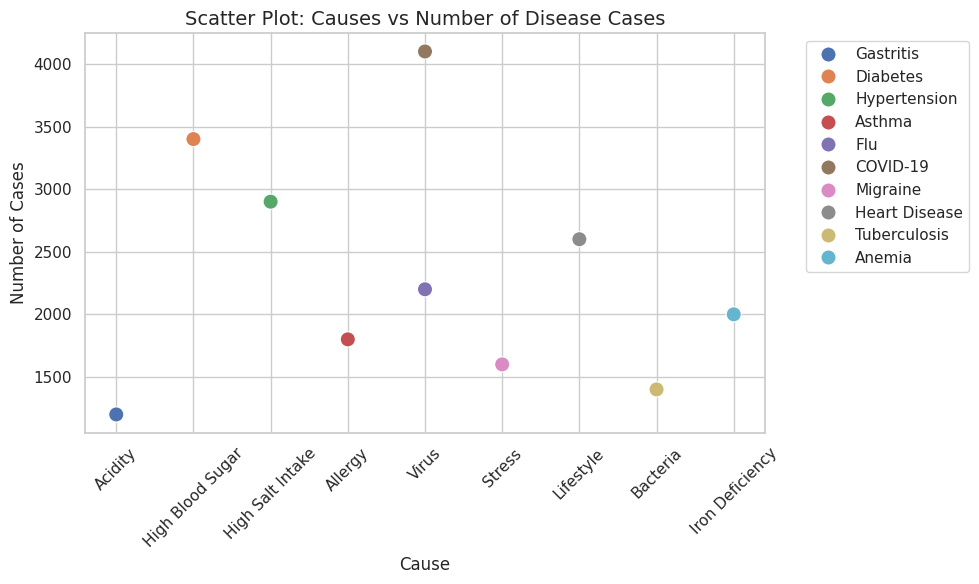

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="Cause",
    y="Number_of_Cases",
    hue="Disease",
    s=120
)

plt.xticks(rotation=45)
plt.title("Scatter Plot: Causes vs Number of Disease Cases", fontsize=14)
plt.xlabel("Cause")
plt.ylabel("Number of Cases")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


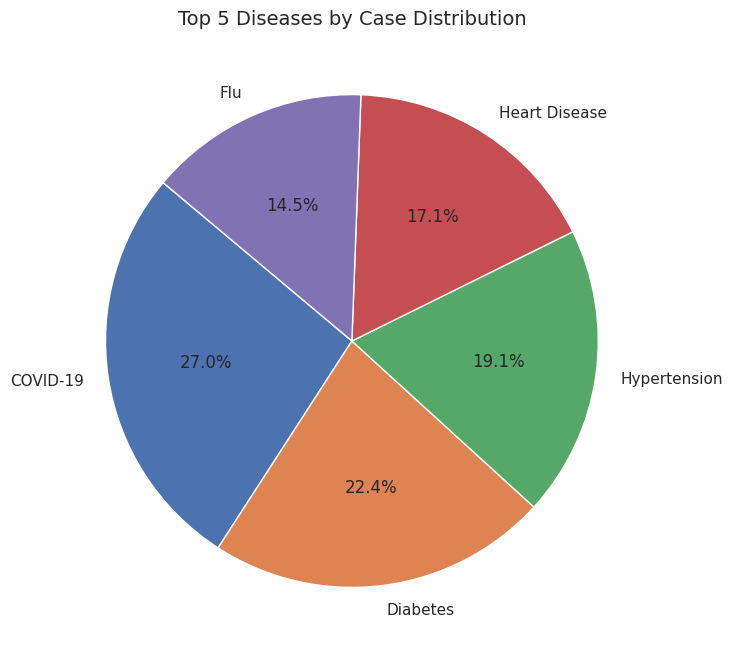

In [ ]:
top_diseases = df.sort_values(by="Number_of_Cases", ascending=False).head(5)

plt.figure(figsize=(8,8))
plt.pie(
    top_diseases["Number_of_Cases"],
    labels=top_diseases["Disease"],
    autopct="%1.1f%%",
    startangle=140
)

plt.title("Top 5 Diseases by Case Distribution", fontsize=14)
plt.show()


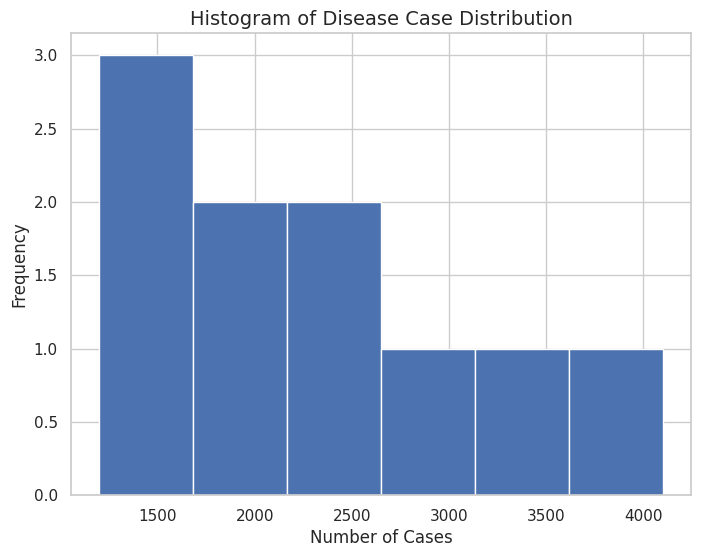

In [ ]:
plt.figure(figsize=(8,6))
plt.hist(df["Number_of_Cases"], bins=6)

plt.title("Histogram of Disease Case Distribution", fontsize=14)
plt.xlabel("Number of Cases")
plt.ylabel("Frequency")
plt.show()


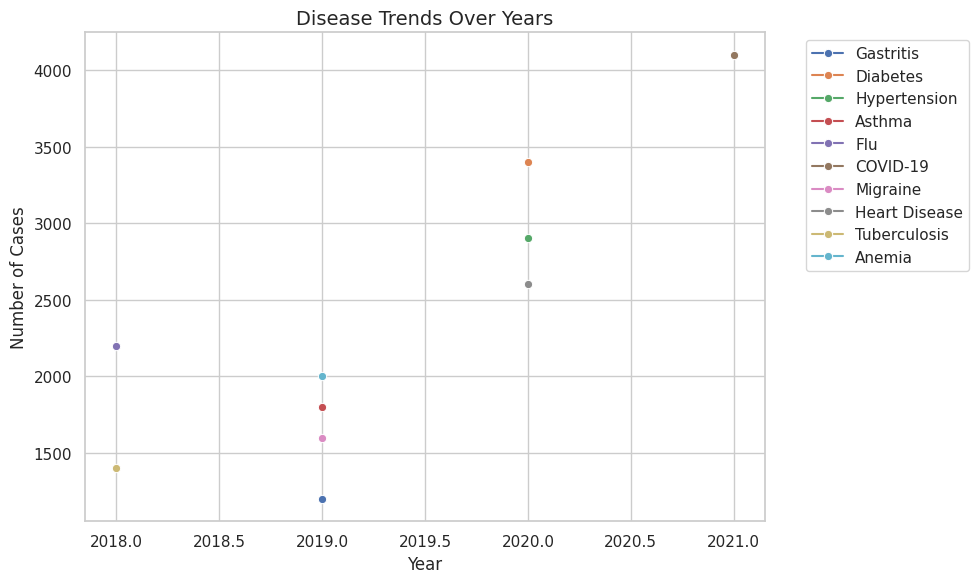

In [ ]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=df,
    x="Year",
    y="Number_of_Cases",
    hue="Disease",
    marker="o"
)

plt.title("Disease Trends Over Years", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Number of Cases")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
df["Expected_Severity"] = [
    "Low",      # Gastritis
    "High",     # Diabetes
    "High",     # Hypertension
    "Medium",   # Asthma
    "Low",      # Flu
    "High",     # COVID-19
    "Medium",   # Migraine
    "High",     # Heart Disease
    "High",     # Tuberculosis
    "Medium"    # Anemia
]


In [ ]:
df["Predicted_Severity"] = [
    "Low", "High", "High", "Medium", "Low",
    "High", "Medium", "High", "Medium", "Medium"
]


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Expected_Label"] = encoder.fit_transform(df["Expected_Severity"])
df["Predicted_Label"] = encoder.transform(df["Predicted_Severity"])


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(df["Expected_Label"], df["Predicted_Label"])
precision = precision_score(df["Expected_Label"], df["Predicted_Label"], average="weighted")
recall = recall_score(df["Expected_Label"], df["Predicted_Label"], average="weighted")
f1 = f1_score(df["Expected_Label"], df["Predicted_Label"], average="weighted")

print("📊 Model Performance Metrics")
print(f"Accuracy  : {accuracy:.2f}")
print(f"Precision : {precision:.2f}")
print(f"Recall    : {recall:.2f}")
print(f"F1 Score  : {f1:.2f}")


📊 Model Performance Metrics
Accuracy  : 0.90
Precision : 0.93
Recall    : 0.90
F1 Score  : 0.90


In [ ]:
z

+